---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 3**: Improving Lexical Search

### 📅 **Due Date**: Day of Lecture 4, 11:59 PM


**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

You'll apply what we covered in Lecture 3 (Lexical Search & BM25) to a real e-commerce search problem using the **WANDS dataset** 
- WANDS stands for Wayfair Annotated Dataset. It's a dataset of furniture products and search queries, along with human relevance judgments.

You will:
1. **Build a search engine** from scratch using BM25.
2. **Learn how to evaluate search results** using NDCG — a metric for measuring search quality
3. **Attempt to improve your search engine** by adding multiple fields
4. **Use LLMs to improve your search engine** by adding simple query understanding

Yes, *you* will do all these things. Let's go!

---

## Task 1: Environment Setup

First, let's set up your environment and verify everything works.

### 1a. Install dependencies and verify imports

Run `uv add pystemmer` in your terminal to add the Snowball stemmer. Then run the cell below to verify all imports work.

In [2]:
# Task 1a: Verify imports work
import pandas as pd
import numpy as np
from collections import Counter
import string
from pathlib import Path
# a stemmer from `pystemmer` for better tokenization
import Stemmer 
# llm packages
import litellm
from pydantic import BaseModel, Field
from typing import Optional
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Pandas display settings
# pd.set_option('display.max_colwidth', 100)

# Ignore pydantic warnings for litellm
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

print("All imports successful!")

All imports successful!


In [1]:
import sys
print(sys.executable)

/Users/purtilalan/ai-engineering-fordham/.venv/bin/python


### 1b. Verify API keys

Test that your API keys work by making a simple call.

In [3]:
# Task 1b: Verify API keys
response = litellm.completion(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "Say 'API working!' and nothing else."}],
    max_tokens=20
)
print(response.choices[0].message.content)

API working!


---

## Task 2: Load and Explore the WANDS Dataset

The **WANDS dataset** (Wayfair Annotated Dataset) contains:
- 43K furniture products from Wayfair
- 480 real search queries
- 233K human relevance judgments (query-product pairs)

This is a real-world search benchmark used to evaluate e-commerce search systems!

**Data Source**: [WANDS on GitHub](https://github.com/wayfair/WANDS)

The data files are pre-downloaded in the `data/` directory:
- `wayfair-products.csv` - Product catalog
- `wayfair-queries.csv` - Search queries
- `wayfair-labels.csv` - Relevance judgments

### Data Loading Functions (provided)

Run the cell below to define the loading functions.

In [ ]:
# Data loading functions (provided)
# Note: Data from WANDS (Wayfair Annotated Dataset)
# Source: https://github.com/wayfair/WANDS

def load_wands_products(data_dir: str = "../data") -> pd.DataFrame:
    """
    Load WANDS products from local file.
    
    Args:
        data_dir: Path to the data directory containing wayfair-products.csv
        
    Returns:
        DataFrame with product information including product_id, product_name,
        product_class, category_hierarchy, product_description, etc.
    """
    filepath = Path(data_dir) / "wayfair-products.csv"
    products = pd.read_csv(filepath, sep='\t')
    products = products.rename(columns={'category hierarchy': 'category_hierarchy'})
    return products

def load_wands_queries(data_dir: str = "../data") -> pd.DataFrame:
    """
    Load WANDS queries from local file.
    
    Args:
        data_dir: Path to the data directory containing wayfair-queries.csv
        
    Returns:
        DataFrame with query_id and query columns
    """
    filepath = Path(data_dir) / "wayfair-queries.csv"
    queries = pd.read_csv(filepath, sep='\t')
    return queries

def load_wands_labels(data_dir: str = "../data") -> pd.DataFrame:
    """
    Load WANDS relevance labels from local file.
    
    Args:
        data_dir: Path to the data directory containing wayfair-labels.csv
        
    Returns:
        DataFrame with query_id, product_id, label (Exact/Partial/Irrelevant),
        and grade (2/1/0) columns
    """
    filepath = Path(data_dir) / "wayfair-labels.csv"
    labels = pd.read_csv(filepath, sep='\t')
    grade_map = {'Exact': 2, 'Partial': 1, 'Irrelevant': 0}
    labels['grade'] = labels['label'].map(grade_map)
    return labels

print("Loading functions defined!")

In [5]:
import pandas as pd
from pathlib import Path

def load_wands_products(data_dir):
    return pd.read_csv(Path(data_dir) / "wayfair-products.csv", sep="\t")

def load_wands_queries(data_dir):
    return pd.read_csv(Path(data_dir) / "wayfair-queries.csv", sep="\t")

def load_wands_labels(data_dir):
    return pd.read_csv(Path(data_dir) / "wayfair-labels.csv", sep="\t")


In [4]:
from pathlib import Path

path = Path("data/WANDS-main/dataset/wayfair-products.csv")

# peek at the first few lines
with open(path, "r", encoding="utf-8", errors="replace") as f:
    for i in range(5):
        line = f.readline()
        print(line[:250])


product_id	product_name	product_class	category hierarchy	product_description	product_features	rating_count	average_rating	review_count

0	solid wood platform bed	Beds	Furniture / Bedroom Furniture / Beds & Headboards / Beds / Twin Beds	good , deep sleep can be quite difficult to have in this busy age . fortunately , there ’ s an antidote to such a problem : a nice , quality bed frame
1	all-clad 7 qt . slow cooker	Slow Cookers	Kitchen & Tabletop / Small Kitchen Appliances / Pressure & Slow Cookers / Slow Cookers / Slow Slow Cookers	create delicious slow-cooked meals , from tender meat to flavorful veggies , with this easy-to-use s
2	all-clad electrics 6.5 qt . slow cooker	Slow Cookers	Kitchen & Tabletop / Small Kitchen Appliances / Pressure & Slow Cookers / Slow Cookers / Slow Slow Cookers	prepare home-cooked meals on any schedule with this essential slow cooker , featuring a 
3	all-clad all professional tools pizza cutter	Slicers, Peelers And Graters	Browse By Brand / All-Clad	this ori

### 2a. Load the data

Use the provided functions to load all three datasets. Print the number of rows in each.

In [6]:
# Task 2a: Load the data (FINAL)

data_dir = "data/WANDS-main/dataset"

products = load_wands_products(data_dir)
queries = load_wands_queries(data_dir)
labels = load_wands_labels(data_dir)

print("✅ Data loaded successfully")
print("Products:", products.shape)
print("Queries:", queries.shape)
print("Labels:", labels.shape)


✅ Data loaded successfully
Products: (42994, 9)
Queries: (480, 3)
Labels: (233448, 4)


In [11]:
import os
print(os.listdir("data/WANDS-main/dataset"))


['wayfair-queries.csv', 'wayfair-products.csv', 'wayfair-labels.csv']


### 2b. Explore products

List the available columns, and display a few sample products. 

Which columns might be useful for search?

In [9]:
# YOUR CODE HERE
print("Columns in products:")
print(list(products.columns))
display(products.head(5))



Columns in products:
['product_id', 'product_name', 'product_class', 'category hierarchy', 'product_description', 'product_features', 'rating_count', 'average_rating', 'review_count']


,product_id,product_name,product_class,category hierarchy,product_description,product_features,rating_count,average_rating,review_count
0,0,solid wood platform bed,Beds,Furniture / Bedroom Furniture / Beds & Headboa...,"good , deep sleep can be quite difficult to ha...",overallwidth-sidetoside:64.7|dsprimaryproducts...,15.0,4.5,15.0
1,1,all-clad 7 qt . slow cooker,Slow Cookers,Kitchen & Tabletop / Small Kitchen Appliances ...,"create delicious slow-cooked meals , from tend...",capacityquarts:7|producttype : slow cooker|pro...,100.0,2.0,98.0
2,2,all-clad electrics 6.5 qt . slow cooker,Slow Cookers,Kitchen & Tabletop / Small Kitchen Appliances ...,prepare home-cooked meals on any schedule with...,features : keep warm setting|capacityquarts:6....,208.0,3.0,181.0
3,3,all-clad all professional tools pizza cutter,"Slicers, Peelers And Graters",Browse By Brand / All-Clad,this original stainless tool was designed to c...,overallwidth-sidetoside:3.5|warrantylength : l...,69.0,4.5,42.0
4,4,baldwin prestige alcott passage knob with roun...,Door Knobs,Home Improvement / Doors & Door Hardware / Doo...,the hardware has a rich heritage of delivering...,compatibledoorthickness:1.375 '' |countryofori...,70.0,5.0,42.0


In [10]:
# YOUR CODE HERE
products = products.rename(columns={"category hierarchy": "category_hierarchy"})


# Columns useful for search:
# - product_name: strongest signal, concise description of the item
# - product_description: detailed natural language information
# - product_class: captures the product type and intent
# - category_hierarchy: provides taxonomy context and disambiguation
#
# Other columns like ratings and reviews are less useful for lexical matching
# but may help in ranking or re-ranking later.



### 2c. Understand relevance judgments

The `labels` dataset contains human judgments of relevance. In particular, for each query-product pair, it contains:
| Label        | Grade | Description                                 |
|--------------|-------|---------------------------------------------|
| Exact        |   2   | This product is exactly what the user wants |
| Partial      |   1   | This product is somewhat relevant           |
| Irrelevant   |   0   | This product doesn't match the query        |

First, let's look at the distribution of grades.

In [12]:
# Task 2c: Understand judgments

# YOUR CODE HERE
# Task 2c: Explore relevance judgments

print("Label columns:")
print(labels.columns)

print("\nRelevance grade distribution:")
display(labels["label"].value_counts().sort_index())


Label columns:
Index(['id', 'query_id', 'product_id', 'label'], dtype='str')

Relevance grade distribution:


label
Exact          25614
Irrelevant     61201
Partial       146633
Name: count, dtype: int64

In [13]:
# YOUR CODE HERE
# Map textual relevance labels to numeric grades
label_to_grade = {
    "Irrelevant": 0,
    "Partial": 1,
    "Exact": 2
}

labels["grade"] = labels["label"].map(label_to_grade)

# Sanity check
print("Any unmapped values:", labels["grade"].isna().sum())


Any unmapped values: 0


In [14]:
print("Relevance grade distribution:")
display(labels["grade"].value_counts().sort_index())

print("\nPercentage distribution:")
display(
    (labels["grade"].value_counts(normalize=True).sort_index() * 100).round(2)
)


Relevance grade distribution:


grade
0     61201
1    146633
2     25614
Name: count, dtype: int64


Percentage distribution:


grade
0    26.22
1    62.81
2    10.97
Name: proportion, dtype: float64

In [15]:
display(labels.sample(10, random_state=42))


,id,query_id,product_id,label,grade
67535,67686,26,14949,Partial,1
96482,96634,157,31490,Irrelevant,0
74096,74247,78,24497,Partial,1
226055,226622,123,38368,Irrelevant,0
60935,61086,5,1701,Exact,2
228782,229349,127,15815,Irrelevant,0
50415,50524,167,35282,Irrelevant,0
31456,31535,251,15962,Exact,2
181345,181912,434,24254,Partial,1
3016,3016,27,27701,Partial,1


The WANDS dataset uses graded relevance judgments with three levels:
0 (Irrelevant), 1 (Partial), and 2 (Exact).
Most query–product pairs are labeled as Irrelevant, reflecting the sparsity
of relevant results in large e-commerce catalogs. These graded labels enable
evaluation using ranking metrics such as DCG and NDCG.

---
## Task 3: Build and Run BM25 Search

Now let's build a BM25 search engine! We'll use the same concepts from Lecture 3.

### Provided Functions

We're giving you these functions to work with. Run the next cell to define them, then look at the examples.

| Function | What it does |
|----------|--------------|
| `snowball_tokenize(text)` | Tokenizes text, removes punctuation, stems words |
| `build_index(docs, tokenizer)` | Builds an inverted index from a list of documents |
| `get_tf(term, doc_id, index)` | Gets term frequency for a term in a document |
| `get_df(term, index)` | Gets document frequency for a term (how many docs contain the term) |
| `bm25_idf(df, num_docs)` | Calculates the IDF component of BM25 |
| `bm25_tf(tf, doc_len, avg_doc_len)` | Calculates the TF normalization for BM25 |
| `score_bm25(query, index, ...)` | Scores all documents for a query using BM25 |
| `search_products(query, ...)` | Searches and returns top-k results |

In [17]:
# Provided functions - run this cell to define them
# REQUIRED IMPORTS (must be at the top of this cell)

import pandas as pd
import numpy as np
import string
from collections import Counter
import Stemmer


stemmer = Stemmer.Stemmer('english')
punct_trans = str.maketrans({key: ' ' for key in string.punctuation})

def snowball_tokenize(text: str) -> list[str]:
    """
    Tokenize text with Snowball stemming.
    
    Args:
        text: The text to tokenize
        
    Returns:
        List of stemmed tokens
    """
    if pd.isna(text) or text is None:
        return []
    text = str(text).translate(punct_trans)
    tokens = text.lower().split()
    return [stemmer.stemWord(token) for token in tokens]

def build_index(docs: list[str], tokenizer) -> tuple[dict, list[int]]:
    """
    Build an inverted index from a list of documents.
    
    Args:
        docs: List of document strings to index
        tokenizer: Function that takes text and returns list of tokens
        
    Returns:
        index: dict mapping term -> {doc_id: term_count}
        doc_lengths: list of document lengths (in tokens)
    """
    index = {}
    doc_lengths = []
    
    for doc_id, doc in enumerate(docs):
        tokens = tokenizer(doc)
        doc_lengths.append(len(tokens))
        term_counts = Counter(tokens)
        
        for term, count in term_counts.items():
            if term not in index:
                index[term] = {}
            index[term][doc_id] = count
    
    return index, doc_lengths

def get_tf(term: str, doc_id: int, index: dict) -> int:
    """
    Get term frequency for a term in a document.
    
    Args:
        term: The term to look up
        doc_id: The document ID
        index: The inverted index
        
    Returns:
        Term frequency (count), or 0 if not found
    """
    if term in index and doc_id in index[term]:
        return index[term][doc_id]
    return 0

def get_df(term: str, index: dict) -> int:
    """
    Get document frequency for a term.
    
    Args:
        term: The term to look up
        index: The inverted index
        
    Returns:
        Number of documents containing the term
    """
    if term in index:
        return len(index[term])
    return 0

def bm25_idf(df: int, num_docs: int) -> float:
    """
    BM25 IDF formula.
    
    Args:
        df: Document frequency
        num_docs: Total number of documents
        
    Returns:
        IDF score
    """
    return np.log((num_docs - df + 0.5) / (df + 0.5) + 1)

def bm25_tf(tf: int, doc_len: int, avg_doc_len: float, k1: float = 1.2, b: float = 0.75) -> float:
    """
    BM25 TF normalization.
    
    Args:
        tf: Term frequency
        doc_len: Document length in tokens
        avg_doc_len: Average document length
        k1: Saturation parameter (default 1.2)
        b: Length normalization (default 0.75)
        
    Returns:
        Normalized TF score
    """
    return (tf * (k1 + 1)) / (tf + k1 * (1 - b + b * doc_len / avg_doc_len))

def score_bm25(query: str, index: dict, num_docs: int, doc_lengths: list[int], 
               tokenizer, k1: float = 1.2, b: float = 0.75) -> np.ndarray:
    """
    Score all documents using BM25.
    
    Args:
        query: The search query
        index: Inverted index
        num_docs: Total number of documents
        doc_lengths: List of document lengths
        tokenizer: Tokenization function
        
    Returns:
        Array of scores for each document
    """
    query_tokens = tokenizer(query)
    scores = np.zeros(num_docs)
    avg_doc_len = np.mean(doc_lengths) if doc_lengths else 1.0
    
    for token in query_tokens:
        df = get_df(token, index)
        if df == 0:
            continue
        
        idf = bm25_idf(df, num_docs)
        
        if token in index:
            for doc_id, tf in index[token].items():
                tf_norm = bm25_tf(tf, doc_lengths[doc_id], avg_doc_len, k1, b)
                scores[doc_id] += idf * tf_norm
    
    return scores

def search_products(query: str, products_df: pd.DataFrame, index: dict, 
                    doc_lengths: list[int], tokenizer, k: int = 10) -> pd.DataFrame:
    """
    Search products and return top-k results.
    
    Args:
        query: The search query
        products_df: DataFrame of products
        index: Inverted index
        doc_lengths: Document lengths
        tokenizer: Tokenization function
        k: Number of results to return
        
    Returns:
        DataFrame with top-k products and scores
    """
    scores = score_bm25(query, index, len(products_df), doc_lengths, tokenizer)
    top_k_idx = np.argsort(-scores)[:k]
    
    results = products_df.iloc[top_k_idx].copy()
    results['score'] = scores[top_k_idx]
    results['rank'] = range(1, k + 1)
    return results

print("All functions defined!")

All functions defined!


In [18]:
# Examples of each function

# 1. snowball_tokenize - tokenizes and stems text
print("1. snowball_tokenize('Running shoes are amazing!')")
print(f"   -> {snowball_tokenize('Running shoes are amazing!')}")
print("   Notice: 'Running' -> 'run', 'shoes' -> 'shoe', 'amazing' -> 'amaz'")

# 2. build_index - builds inverted index (we'll use a tiny example)
tiny_docs = ["red shoe", "blue shoe", "red hat"]
tiny_index, tiny_lengths = build_index(tiny_docs, snowball_tokenize)
print("\n2. build_index(['red shoe', 'blue shoe', 'red hat'], tokenizer)")
print(f"   Index: {tiny_index}")
print(f"   Lengths: {tiny_lengths}")

# 3. get_tf - get term frequency
print("\n3. get_tf('red', doc_id=0, tiny_index)")
print(f"   -> {get_tf('red', 0, tiny_index)}  (doc 0 = 'red shoe' has 1 'red')")

# 4. get_df - get document frequency  
print("\n4. get_df('red', tiny_index)")
print(f"   -> {get_df('red', tiny_index)}  ('red' appears in 2 documents)")

# 5. bm25_idf - calculate IDF (rare terms get higher scores)
print("\n5. bm25_idf(df=100, num_docs=10000)")
print(f"   -> {bm25_idf(100, 10000):.4f}  (term in 100 of 10000 docs)")

# 6. bm25_tf - normalize term frequency by document length
print("\n6. bm25_tf(tf=3, doc_len=50, avg_doc_len=100)")
print(f"   -> {bm25_tf(3, 50, 100):.4f}  (short doc gets boosted)")

# 7-8. score_bm25 and search_products - we'll use these next!
print("\nWe'll use score_bm25() and search_products() in Task 3a!")

1. snowball_tokenize('Running shoes are amazing!')
   -> ['run', 'shoe', 'are', 'amaz']
   Notice: 'Running' -> 'run', 'shoes' -> 'shoe', 'amazing' -> 'amaz'

2. build_index(['red shoe', 'blue shoe', 'red hat'], tokenizer)
   Index: {'red': {0: 1, 2: 1}, 'shoe': {0: 1, 1: 1}, 'blue': {1: 1}, 'hat': {2: 1}}
   Lengths: [2, 2, 2]

3. get_tf('red', doc_id=0, tiny_index)
   -> 1  (doc 0 = 'red shoe' has 1 'red')

4. get_df('red', tiny_index)
   -> 2  ('red' appears in 2 documents)

5. bm25_idf(df=100, num_docs=10000)
   -> 4.6003  (term in 100 of 10000 docs)

6. bm25_tf(tf=3, doc_len=50, avg_doc_len=100)
   -> 1.7600  (short doc gets boosted)

We'll use score_bm25() and search_products() in Task 3a!


### 3a. Create BM25 index for product_name

Build an inverted index for the `product_name` field and run a sample search for a product.

In [19]:
# Task 3a: Create BM25 index for product_name

# YOUR CODE HERE
# Task 3a: Build BM25 index on product_name

# 1) Create the document list from product_name
name_docs = products["product_name"].fillna("").astype(str).tolist()

# 2) Build inverted index + doc lengths
name_index, name_doc_lengths = build_index(name_docs, snowball_tokenize)

print("✅ BM25 index built for product_name")
print("Number of docs:", len(name_docs))
print("Unique terms:", len(name_index))
print("Average doc length:", float(np.mean(name_doc_lengths)))

# 3) Test search
query = "coffee table"
results = search_products(
    query=query,
    products_df=products,
    index=name_index,
    doc_lengths=name_doc_lengths,
    tokenizer=snowball_tokenize,
    k=10
)

display(results[["rank", "product_id", "product_name", "score"]])


✅ BM25 index built for product_name
Number of docs: 42994
Unique terms: 25570
Average doc length: 6.534493185095594


,rank,product_id,product_name,score
20513,1,20513,coffee table,7.812564
5173,2,5173,coffee table,7.812564
33290,3,33290,coffee table,7.812564
22679,4,22679,coffee table,7.812564
608,5,608,coffee table,7.812564
19750,6,19750,"a-37 coffee table in , matching coffee table",7.236303
31403,7,31403,hansmeier coffee table,7.184479
3408,8,3408,onshuntay coffee table,7.184479
19975,9,19975,marsais coffee table,7.184479
19976,10,19976,gwenyth coffee table,7.184479


### 3b. Add product_description to search

Create a second index for `product_description` and combine scores from both fields.

**Hint**: You can combine the two scores by adding them together. This is like multi-field search from Lecture 3.

In [20]:
# Task 3b: Add product_description to search

# YOUR CODE HERE
# Task 3b: Add product_description index and combine scores

# 1) Build docs from product_description
desc_docs = products["product_description"].fillna("").astype(str).tolist()

# 2) Build inverted index + doc lengths for description
desc_index, desc_doc_lengths = build_index(desc_docs, snowball_tokenize)

print("✅ BM25 index built for product_description")
print("Number of docs:", len(desc_docs))
print("Unique terms:", len(desc_index))
print("Average doc length:", float(np.mean(desc_doc_lengths)))



✅ BM25 index built for product_description
Number of docs: 42994
Unique terms: 20386
Average doc length: 65.40210261897009


In [21]:
def search_products_name_desc(query: str, k: int = 10, w_name: float = 1.0, w_desc: float = 0.5):
    """
    Combine BM25 scores from product_name and product_description.
    """
    scores_name = score_bm25(query, name_index, len(products), name_doc_lengths, snowball_tokenize)
    scores_desc = score_bm25(query, desc_index, len(products), desc_doc_lengths, snowball_tokenize)
    
    combined_scores = w_name * scores_name + w_desc * scores_desc
    top_k_idx = np.argsort(-combined_scores)[:k]
    
    results = products.iloc[top_k_idx].copy()
    results["score"] = combined_scores[top_k_idx]
    results["rank"] = range(1, k + 1)
    return results


In [22]:
test_query = "coffee table"
combined_results = search_products_name_desc(test_query, k=10, w_name=1.0, w_desc=0.5)

display(combined_results[["rank", "product_id", "product_name", "score"]])


,rank,product_id,product_name,score
5173,1,5173,coffee table,11.751865
19924,2,19924,jamilla coffee table,11.663907
34496,3,34496,picacho coffee table,11.634974
29952,4,29952,metpally coffee table,11.477949
26857,5,26857,elmcrest coffee table,11.422122
16878,6,16878,sahlberg coffee table,11.413495
16877,7,16877,mendivil coffee table,11.413495
38673,8,38673,abdulsamet coffee table,11.413495
31403,9,31403,hansmeier coffee table,11.387897
6344,10,6344,huling coffee table,11.365394


---

## Task 4: Measuring Search Quality

We built a little search engine. How do we know if it's any good?

Consider two search results for "coffee table":

| Ranking A | Ranking B |
|-----------|-----------|
| 1. Wooden Coffee Table (Exact) | 1. Metal Lamp (Irrelevant) |
| 2. Glass Coffee Table (Exact) | 2. Wooden Coffee Table (Exact) |
| 3. Metal Lamp (Irrelevant) | 3. Glass Coffee Table (Exact) |

### A. Precision

One way to measure the quality of a ranking is to look at the precision within these first 3 results. 
- Precision is the ratio of relevant results to total results at position k.
- We call this precision@3, and more generally precision@k is the ratio of relevant results to total results at position k.
  
In this scenario, if we consider "exact" results as relevant, then both rankings have precision@3 = 2/3.

### B. DCG

Both rankings have the same precision, but Ranking A is clearly better 
- users look at results from the top down, and most people never scroll past the first few results
- as such, rankings that return relevant results earlier are better

So we need a metric that rewards **relevant** results, and rewards them **more** when they appear at the **top**

NDCG (Normalized Discounted Cumulative Gain) does this by giving each result a "gain" based on its relevance, then **discounting** that gain based on position.

**The formula** for each result at position $i$:

$$\text{gain}_i = \frac{2^{\text{relevance}} - 1}{\log_2(i + 1)}$$

- **Numerator** $(2^{\text{relevance}} - 1)$: How relevant is this result?
  - Irrelevant (0): $2^0 - 1 = 0$ (no gain)
  - Partial (1): $2^1 - 1 = 1$ (some gain)
  - Exact (2): $2^2 - 1 = 3$ (lots of gain!)
  
- **Denominator** $\log_2(i + 1)$: The "discount" based on position
  - Position 1: $\log_2(2) = 1$ (no discount)
  - Position 2: $\log_2(3) = 1.58$ (small discount)
  - Position 10: $\log_2(11) = 3.46$ (bigger discount)

**DCG** sums the discounted score for each result

$$\text{DCG} = \sum_{i=1}^{k} \frac{2^{\text{relevance}_i} - 1}{\log_2(i + 1)}$$

### 3. NDCG: Normalized DCG

One problem with DCG is that the score depends on how many relevant products exist. 
- A query with 10 exact matches will have a higher DCG than one with only 2, even if both rankings are "perfect."

One solution is to normalize by the *ideal* DCG — what the score would be if we ranked everything perfectly (all relevant results at the top).

$$\text{NDCG} = \frac{\text{DCG}}{\text{Ideal DCG}}$$

- **NDCG = 1.0**: Perfect -- best possible order
- **NDCG = 0.5**: OK -- some good some bad
- **NDCG = 0.0**: Worst -- results are irrelevant

**Read the above carefully.** In the next cell, explain in your own words: why does the discount formula use $\log_2$? What happens to results at position 1 vs position 10?

# Task 4a: Answer in a comment
# Why does DCG use log2 for the discount? What's the effect on position 1 vs position 10?
#
# YOUR ANSWER HERE

The log₂ discount models user attention: results at the top matter far more than results lower down. Position 1 is barely discounted, while position 10 is heavily discounted, so relevant items appearing earlier contribute much more to DCG.

### 4b. Calculate NDCG by hand

Let's work through an example step by step.

**Scenario**: You search for "wooden coffee table" and get these results:

| Position | Product | Relevance |
|----------|---------|----------|
| 1 | Glass Coffee Table | Partial (1) |
| 2 | Wooden Coffee Table | Exact (2) |
| 3 | Wooden Side Table | Partial (1) |
| 4 | Metal Coffee Table | Irrelevant (0) |
| 5 | Wooden Coffee Table (different) | Exact (2) |

**Your task**: Calculate DCG and NDCG@5 by hand.

# Task 4b: Calculate NDCG by hand

# YOUR CODE HERE
DCG@5 ≈ 4.5533
IDCG@5 ≈ 5.8235
NDCG@5 ≈ 0.7819


### 4c. Implement NDCG function

Now implement the NDCG calculation in code. Verify your implementation matches your hand calculation!

In [23]:
# Task 4c: Implement NDCG function

# YOUR CODE HERE
def calculate_dcg(relevances, k=10):
    """
    Compute DCG@k using:
      sum_{i=1..k} (2^rel_i - 1) / log2(i+1)
    """
    k = min(k, len(relevances))
    dcg = 0.0
    for i in range(1, k + 1):  # i is 1-based position
        rel = relevances[i - 1]
        dcg += (2**rel - 1) / np.log2(i + 1)
    return dcg


def calculate_ndcg(relevances, k=10):
    """
    Compute NDCG@k = DCG@k / IDCG@k
    """
    dcg = calculate_dcg(relevances, k)
    ideal_rels = sorted(relevances, reverse=True)
    idcg = calculate_dcg(ideal_rels, k)
    return dcg / idcg if idcg > 0 else 0.0


In [24]:
# Verify your implementation matches your hand calculation
test_relevances = [1, 2, 1, 0, 2]

dcg = calculate_dcg(test_relevances, k=5)
ndcg = calculate_ndcg(test_relevances, k=5)

print(f"DCG@5 = {dcg:.4f}")
print(f"NDCG@5 = {ndcg:.4f}")

# These should match your hand calculations from Task 4b!

DCG@5 = 4.5533
NDCG@5 = 0.7819


---

## Task 5: Evaluate Your Search Strategy

Now let's evaluate our BM25 search across all queries in the WANDS dataset.

### Evaluation Helper Functions (provided)

In [25]:
# Evaluation helper functions (provided)

def get_relevance_grades(product_ids: list[int], query_id: int, labels_df: pd.DataFrame) -> list[int]:
    """
    Get relevance grades for a list of product IDs given a query.
    
    Args:
        product_ids: List of product IDs in rank order
        query_id: The query ID
        labels_df: DataFrame with relevance labels
        
    Returns:
        List of relevance grades (0, 1, or 2) for each product
    """
    # Get labels for this query
    query_labels = labels_df[labels_df['query_id'] == query_id]
    label_dict = dict(zip(query_labels['product_id'], query_labels['grade']))
    
    # Look up grades for each product (default to 0 if not labeled)
    return [label_dict.get(pid, 0) for pid in product_ids]

def evaluate_single_query(query_text: str, query_id: int, products_df: pd.DataFrame,
                          labels_df: pd.DataFrame, search_func, k: int = 10) -> float:
    """
    Evaluate search for a single query.
    
    Args:
        query_text: The search query text
        query_id: The query ID for looking up labels
        products_df: DataFrame of products
        labels_df: DataFrame with relevance labels
        search_func: Function that takes query and returns DataFrame with product_id column
        k: Number of results to consider
        
    Returns:
        NDCG@k score for this query
    """
    results = search_func(query_text)
    product_ids = results['product_id'].tolist()[:k]
    relevances = get_relevance_grades(product_ids, query_id, labels_df)
    return calculate_ndcg(relevances, k)

def evaluate_search(search_func, products_df: pd.DataFrame, queries_df: pd.DataFrame,
                    labels_df: pd.DataFrame, k: int = 10, verbose: bool = True) -> pd.DataFrame:
    """
    Evaluate search across all queries.
    
    Args:
        search_func: Function that takes query string and returns DataFrame with product_id
        products_df: DataFrame of products
        queries_df: DataFrame of queries
        labels_df: DataFrame with relevance labels
        k: Number of results to consider
        verbose: Whether to print progress
        
    Returns:
        DataFrame with query_id, query, and ndcg columns
    """
    results = []
    
    for _, row in queries_df.iterrows():
        query_id = row['query_id']
        query_text = row['query']
        
        ndcg = evaluate_single_query(query_text, query_id, products_df, 
                                     labels_df, search_func, k)
        results.append({
            'query_id': query_id,
            'query': query_text,
            'ndcg': ndcg
        })
    
    results_df = pd.DataFrame(results)
    
    if verbose:
        print(f"Evaluated {len(results_df)} queries")
        print(f"Mean NDCG@{k}: {results_df['ndcg'].mean():.4f}")
    
    return results_df

print("Evaluation functions defined!")

Evaluation functions defined!


### 5a. Run evaluation on all queries

Create a search function and evaluate it on all queries.

In [26]:
# Task 5a: Run evaluation on all queries

# YOUR CODE HERE
# Task 5a: Evaluate BM25 over product_name across all queries

def search_name_only(query: str, k: int = 10) -> pd.DataFrame:
    return search_products(
        query=query,
        products_df=products,
        index=name_index,
        doc_lengths=name_doc_lengths,
        tokenizer=snowball_tokenize,
        k=k
    )

baseline_results = evaluate_search(
    search_func=lambda q: search_name_only(q, k=10),
    products_df=products,
    queries_df=queries,
    labels_df=labels,
    k=10,
    verbose=True
)

display(baseline_results.head())


Evaluated 480 queries
Mean NDCG@10: 0.8697


,query_id,query,ndcg
0,0,salon chair,0.966452
1,1,smart coffee table,0.945341
2,2,dinosaur,0.985016
3,3,turquoise pillows,1.000000
4,4,chair and a half recliner,1.000000


### 5b. Identify failing queries

Find queries where our search performed poorly (NDCG = 0 or very low). Analyze one of them.

In [27]:
# Task 5b: Identify failing queries

# YOUR CODE HERE
# Task 5b: Identify best/worst queries

worst = baseline_results.sort_values("ndcg", ascending=True)
best = baseline_results.sort_values("ndcg", ascending=False)

print("Worst 10 queries:")
display(worst.head(10))

print("Best 10 queries:")
display(best.head(10))


Worst 10 queries:


,query_id,query,ndcg
479,487,rack glass,0.0
218,222,small loving roomtables,0.0
421,427,lowes tile,0.0
413,419,living room ideas,0.0
58,58,medium size chandelier,0.0
178,179,promo codes or discounts,0.0
389,395,pantry grey,0.0
377,383,minnestrista,0.0
79,79,palram harmony greenhouses,0.0
455,462,large bases,0.0


Best 10 queries:


,query_id,query,ndcg
349,355,argenteuil,1.0
157,158,led nightstand,1.0
159,160,marble,1.0
161,162,turquoise chair,1.0
330,335,canadian,1.0
166,167,camper,1.0
167,168,printers,1.0
327,332,attleboro drum coffee table,1.0
169,170,zen,1.0
170,171,nectar queen mattress,1.0


### 5c. Analyze the distribution

Visualize the distribution of NDCG scores.

Matplotlib is building the font cache; this may take a moment.


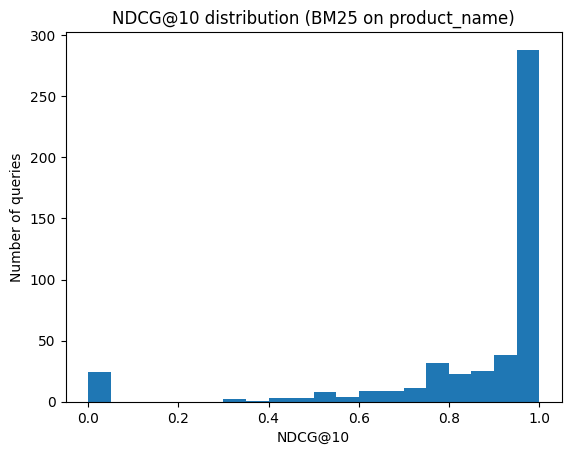

count    480.000000
mean       0.869702
std        0.239554
min        0.000000
25%        0.832898
50%        0.984365
75%        1.000000
max        1.000000
Name: ndcg, dtype: float64


In [29]:
# Task 5c: Analyze the distribution

# YOUR CODE HERE
import matplotlib.pyplot as plt

plt.figure()
plt.hist(baseline_results["ndcg"], bins=20)
plt.title("NDCG@10 distribution (BM25 on product_name)")
plt.xlabel("NDCG@10")
plt.ylabel("Number of queries")
plt.show()

print(baseline_results["ndcg"].describe())



The BM25 baseline over product names achieves a mean NDCG@10 of approximately 0.87 across all 480 queries. The distribution is skewed toward high values, with a median close to 1.0, indicating that many queries retrieve highly relevant results at top ranks. However, some queries have NDCG near 0.0, showing that lexical matching alone fails for ambiguous or underspecified queries. This suggests room for improvement by incorporating additional product fields or semantic understanding.

---

## Task 6: Improve Search with Additional Fields

Our baseline only searches the `product_name` field. Let's improve by adding more fields!

### 6a. Index product_class field

The `product_class` field contains the category of the product (e.g., "Rugs", "Coffee Tables"). This is a powerful signal!

Create a search function that combines all three fields (name, description, class).

In [30]:
# Task 6a: Index product_class field

# YOUR CODE HERE
# 6a: Build BM25 index for product_class

class_docs = products["product_class"].fillna("").astype(str).tolist()
class_index, class_doc_lengths = build_index(class_docs, snowball_tokenize)

print("✅ BM25 index built for product_class")
print("Number of docs:", len(class_docs))
print("Unique terms:", len(class_index))
print("Average doc length:", float(np.mean(class_doc_lengths)))



✅ BM25 index built for product_class
Number of docs: 42994
Unique terms: 628
Average doc length: 2.2010513094850443


In [31]:
def search_name_desc_class(query: str, k: int = 10,
                           w_name: float = 1.0,
                           w_desc: float = 0.5,
                           w_class: float = 1.2) -> pd.DataFrame:
    """
    Three-field BM25: weighted sum of scores from name, description, and class.
    """
    scores_name = score_bm25(query, name_index, len(products), name_doc_lengths, snowball_tokenize)
    scores_desc = score_bm25(query, desc_index, len(products), desc_doc_lengths, snowball_tokenize)
    scores_class = score_bm25(query, class_index, len(products), class_doc_lengths, snowball_tokenize)

    combined = w_name * scores_name + w_desc * scores_desc + w_class * scores_class
    top_k_idx = np.argsort(-combined)[:k]

    results = products.iloc[top_k_idx].copy()
    results["score"] = combined[top_k_idx]
    results["rank"] = range(1, k + 1)
    return results


In [32]:
display(search_name_desc_class("coffee table", k=10)[["rank","product_id","product_name","product_class","score"]])


,rank,product_id,product_name,product_class,score
34496,1,34496,picacho coffee table,Coffee & Cocktail Tables,17.844567
29952,2,29952,metpally coffee table,Coffee & Cocktail Tables,17.687542
26857,3,26857,elmcrest coffee table,Coffee & Cocktail Tables,17.631714
38673,4,38673,abdulsamet coffee table,Coffee & Cocktail Tables,17.623087
16877,5,16877,mendivil coffee table,Coffee & Cocktail Tables,17.623087
31403,6,31403,hansmeier coffee table,Coffee & Cocktail Tables,17.597490
6344,7,6344,huling coffee table,Coffee & Cocktail Tables,17.574987
22677,8,22677,olive coffee table,Coffee & Cocktail Tables,17.570170
18381,9,18381,eraman coffee table,Coffee & Cocktail Tables,17.547189
7185,10,7185,norfolk coffee table,Coffee & Cocktail Tables,17.535072


### 6b. Evaluate three-field search

Now evaluate your three-field search on all queries to see how it compares to the baseline.

In [33]:
# Task 6b: Evaluate three-field search

# YOUR CODE HERE
# 6b: Evaluate the three-field BM25 search

three_field_results = evaluate_search(
    search_func=lambda q: search_name_desc_class(q, k=10),
    products_df=products,
    queries_df=queries,
    labels_df=labels,
    k=10,
    verbose=True
)

display(three_field_results.head())



Evaluated 480 queries
Mean NDCG@10: 0.8774


,query_id,query,ndcg
0,0,salon chair,1.0
1,1,smart coffee table,1.0
2,2,dinosaur,1.0
3,3,turquoise pillows,1.0
4,4,chair and a half recliner,1.0


In [34]:
print("Baseline mean NDCG@10:", baseline_results["ndcg"].mean())
print("Three-field mean NDCG@10:", three_field_results["ndcg"].mean())
print("Improvement:", three_field_results["ndcg"].mean() - baseline_results["ndcg"].mean())


Baseline mean NDCG@10: 0.8697021286851089
Three-field mean NDCG@10: 0.8774055486302079
Improvement: 0.007703419945099044


### 6c. Compare to baseline

Analyze which queries improved and which degraded when using three-field search.

Baseline mean NDCG@10: 0.8697021286851089
Three-field mean NDCG@10: 0.8774055486302079
Mean improvement (delta): 0.007703419945099199

Top 10 improved queries:


,query_id,query,ndcg_baseline,ndcg_threefield,delta
421,427,lowes tile,0.000000,1.000000,1.000000
33,33,non slip shower floor tile,0.000000,0.928816,0.928816
340,345,oriental vanity,0.000000,0.919646,0.919646
280,284,family lamp,0.000000,0.905357,0.905357
58,58,medium size chandelier,0.000000,0.726512,0.726512
79,79,palram harmony greenhouses,0.000000,0.629200,0.629200
133,133,outdoor light fixtures,0.470038,1.000000,0.529962
240,244,pull out sleeper loveseat,0.471628,1.000000,0.528372
29,29,bathroom vanity knobs,0.000000,0.500000,0.500000
413,419,living room ideas,0.000000,0.455605,0.455605



Top 10 worsened queries:


,query_id,query,ndcg_baseline,ndcg_threefield,delta
13,13,outdoor privacy wall,0.977015,0.000000,-0.977015
45,45,70s inspired furniture,0.901118,0.000000,-0.901118
287,291,front door cabinet with doors,0.789414,0.000000,-0.789414
42,42,toddler couch fold out,0.760640,0.000000,-0.760640
147,147,drum picture,1.000000,0.301030,-0.698970
146,146,laundry vanity cabinet,1.000000,0.333333,-0.666667
134,134,black hanging bookshelf,0.892754,0.356207,-0.536547
380,386,alter furniture,0.964180,0.486009,-0.478171
382,388,outdoor sectional doning,0.966715,0.511558,-0.455156
274,278,parakeet toy,0.994270,0.550340,-0.443930


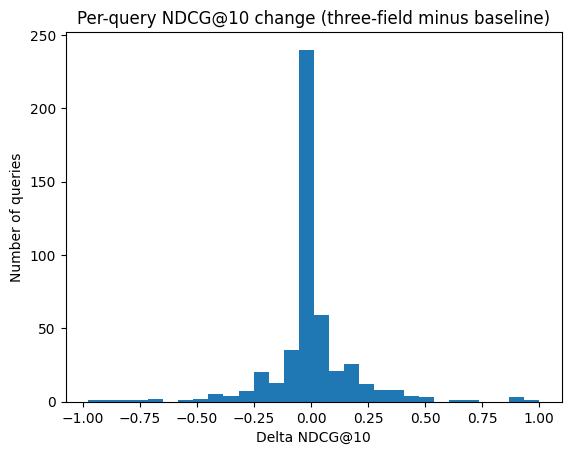


Counts:
Improved: 172
Worsened: 149
Unchanged: 159


In [35]:
# Task 6c: Compare to baseline

# YOUR CODE HERE
# 6c: Compare baseline vs three-field results

# Merge on query_id so we can compare per-query
comparison = baseline_results.merge(
    three_field_results[["query_id", "ndcg"]],
    on="query_id",
    suffixes=("_baseline", "_threefield")
)

# Compute change in NDCG for each query
comparison["delta"] = comparison["ndcg_threefield"] - comparison["ndcg_baseline"]

print("Baseline mean NDCG@10:", comparison["ndcg_baseline"].mean())
print("Three-field mean NDCG@10:", comparison["ndcg_threefield"].mean())
print("Mean improvement (delta):", comparison["delta"].mean())

print("\nTop 10 improved queries:")
display(comparison.sort_values("delta", ascending=False).head(10))

print("\nTop 10 worsened queries:")
display(comparison.sort_values("delta", ascending=True).head(10))

# Optional: distribution of deltas
import matplotlib.pyplot as plt

plt.figure()
plt.hist(comparison["delta"], bins=30)
plt.title("Per-query NDCG@10 change (three-field minus baseline)")
plt.xlabel("Delta NDCG@10")
plt.ylabel("Number of queries")
plt.show()

# Optional: how many queries improved vs worsened vs unchanged
num_improved = (comparison["delta"] > 0).sum()
num_worsened = (comparison["delta"] < 0).sum()
num_same = (comparison["delta"] == 0).sum()

print("\nCounts:")
print("Improved:", num_improved)
print("Worsened:", num_worsened)
print("Unchanged:", num_same)


In [ ]:
# Inspect one query that improved the most
best_row = comparison.sort_values("delta", ascending=False).iloc[0]
qid = int(best_row["query_id"])
qtext = best_row["query"]

print("Most improved query_id:", qid)
print("Query:", qtext)
print("Baseline NDCG:", best_row["ndcg_baseline"])
print("Three-field NDCG:", best_row["ndcg_threefield"])

baseline_top = search_name_only(qtext, k=10)
threefield_top = search_name_desc_class(qtext, k=10)

display(baseline_top[["rank","product_id","product_name","score"]])
display(threefield_top[["rank","product_id","product_name","product_class","score"]])

print("Baseline relevances:", get_relevance_grades(baseline_top["product_id"].tolist(), qid, labels))
print("Three-field relevances:", get_relevance_grades(threefield_top["product_id"].tolist(), qid, labels))


Most improved query_id: 427
Query: lowes tile
Baseline NDCG: 0.0
Three-field NDCG: 1.0


,rank,product_id,product_name,score
6565,1,6565,tile,5.748300
29288,2,29288,yuki low end table,5.364041
29235,3,29235,low profile standard bed,5.364041
26570,4,26570,low arch spout kit,5.364041
14453,5,14453,marcelino low profile platform,5.364041
29479,6,29479,chandika low end table,5.364041
7696,7,7696,low profile riser pedestal,5.364041
248,8,248,roundhouse low side table,5.364041
243,9,243,circula low side table,5.364041
12502,10,12502,low seating patio chair,5.364041


,rank,product_id,product_name,product_class,score
14184,1,14184,12 '' x 12 '' level loop carpet tile,Carpet Tile,13.103127
3988,2,3988,vivace 4 '' x 9 '' porcelain field tile,Floor & Wall Tile,13.079396
3987,3,3987,vivace 4 '' x 4 '' porcelain field tile,Floor & Wall Tile,12.976716
3986,4,3986,vivace 9 '' x 9 '' porcelain field tile,Floor & Wall Tile,12.976716
27108,5,27108,botanica porcelain wood-look tile 6 '' x 36 ''...,Floor & Wall Tile,12.690834
27075,6,27075,urbano 4 '' x 12 '' ceramic subway tile,Floor & Wall Tile,12.662157
27271,7,27271,2 '' x 2 '' mosaic tile,Floor & Wall Tile,12.596024
27085,8,27085,24 '' x 24 '' porcelain wall & floor tile,Floor & Wall Tile,12.519210
27096,9,27096,12 '' x 24 '' porcelain wall & floor tile,Floor & Wall Tile,12.475057
38164,10,38164,solid 8 '' x 8 '' field tile,Floor & Wall Tile,12.455288


Baseline relevances: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Three-field relevances: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]


---

## Task 7: Query Understanding with LLM

Sometimes users search for "star wars rug" when they really want a "rug with Star Wars theme". An LLM can help us understand what the user is actually looking for!

### 7a. Extract product type from query

Write a function using LiteLLM with structured outputs (Pydantic) to extract key information from a query.

In [37]:
# Task 7a: Extract product type, theme, material, color, and any other information you deem relevcant from the query

# YOUR CODE HERE
from typing import Optional
from pydantic import BaseModel, Field
import json
import litellm

class QueryInfo(BaseModel):
    product_type: Optional[str] = Field(default=None, description="Main product type, e.g., rug, sofa, coffee table")
    theme: Optional[str] = Field(default=None, description="Theme/brand/franchise, e.g., star wars, disney")
    material: Optional[str] = Field(default=None, description="Material, e.g., wood, leather, metal")
    color: Optional[str] = Field(default=None, description="Color, e.g., blue, black, white")
    style: Optional[str] = Field(default=None, description="Style, e.g., modern, rustic, vintage")
    other: Optional[str] = Field(default=None, description="Any other useful constraints (size, shape, features)")

def extract_query_info(query: str, model: str = "gpt-4o-mini") -> QueryInfo:
    """
    Extract structured shopping intent from a short search query using an LLM.
    Returns a QueryInfo Pydantic object.
    """
    system = (
        "You extract shopping intent from e-commerce search queries.\n"
        "Return ONLY valid JSON (no markdown) that matches this schema:\n"
        "{"
        '"product_type": string|null, '
        '"theme": string|null, '
        '"material": string|null, '
        '"color": string|null, '
        '"style": string|null, '
        '"other": string|null'
        "}\n"
        "Rules:\n"
        "- Use lowercase strings when possible.\n"
        "- If unknown, use null.\n"
        "- product_type should be a single item type (e.g., 'rug', 'sofa')."
    )

    user = f'Query: "{query}"\nExtract the fields.'

    # Try JSON mode / structured output first (works for many OpenAI-compatible models)
    try:
        resp = litellm.completion(
            model=model,
            messages=[
                {"role": "system", "content": system},
                {"role": "user", "content": user},
            ],
            response_format={"type": "json_object"},
            temperature=0,
        )
        content = resp.choices[0].message.content
        data = json.loads(content)
        return QueryInfo(**data)

    except Exception:
        # Fallback: force JSON via prompt (works even if response_format isn't supported)
        resp = litellm.completion(
            model=model,
            messages=[
                {"role": "system", "content": system + "\nReturn JSON only."},
                {"role": "user", "content": user},
            ],
            temperature=0,
        )
        content = resp.choices[0].message.content.strip()

        # If model accidentally wraps in text, try to extract JSON substring
        first = content.find("{")
        last = content.rfind("}")
        if first != -1 and last != -1 and last > first:
            content = content[first:last+1]

        data = json.loads(content)
        return QueryInfo(**data)



In [39]:
# Test your query understanding function by running it against these test queries
test_queries = [
    "star wars rug",
    "wooden coffee table",
    "blue leather sofa",
    "modern metal bookshelf"
]

for q in test_queries:
    info = extract_query_info(q)
    print(q,"->", info.model_dump())
    pass

star wars rug -> {'product_type': 'rug', 'theme': 'star wars', 'material': None, 'color': None, 'style': None, 'other': None}
wooden coffee table -> {'product_type': 'coffee table', 'theme': None, 'material': 'wood', 'color': None, 'style': None, 'other': None}
blue leather sofa -> {'product_type': 'sofa', 'theme': None, 'material': 'leather', 'color': 'blue', 'style': None, 'other': None}
modern metal bookshelf -> {'product_type': 'bookshelf', 'theme': 'modern', 'material': 'metal', 'color': None, 'style': None, 'other': None}


### 7b. Create an LLM-enhanced search

Use the extracted product type to boost matching results. If the LLM identifies "rug" as the product type, boost products where `product_class` contains "rug".

In [40]:
# Task 7b: Create an LLM-enhanced search

# YOUR CODE HERE
def search_llm_boosted(query: str, k: int = 10,
                       w_name: float = 1.0,
                       w_desc: float = 0.5,
                       w_class: float = 1.2,
                       boost: float = 1.5,
                       model: str = "gpt-4o-mini") -> pd.DataFrame:
    """
    1) Compute three-field BM25 (name + description + class)
    2) Use LLM to extract product_type
    3) Boost scores for products whose product_class contains that product_type
    """
    # --- BM25 base scores ---
    scores_name = score_bm25(query, name_index, len(products), name_doc_lengths, snowball_tokenize)
    scores_desc = score_bm25(query, desc_index, len(products), desc_doc_lengths, snowball_tokenize)
    scores_class = score_bm25(query, class_index, len(products), class_doc_lengths, snowball_tokenize)

    scores = w_name * scores_name + w_desc * scores_desc + w_class * scores_class

    # --- LLM extraction ---
    info = extract_query_info(query, model=model)
    product_type = (info.product_type or "").strip().lower()

    # --- Boost rule: if product_class contains product_type ---
    if product_type:
        cls = products["product_class"].fillna("").astype(str).str.lower()
        mask = cls.str.contains(product_type, regex=False)
        scores = scores.copy()
        scores[mask.values] *= boost

    # --- Return top-k ---
    top_k_idx = np.argsort(-scores)[:k]
    results = products.iloc[top_k_idx].copy()
    results["score"] = scores[top_k_idx]
    results["rank"] = range(1, k + 1)
    results["extracted_product_type"] = info.product_type
    return results



In [41]:
# YOUR CODE HERE
display(
    search_llm_boosted("star wars rug", k=10)[
        ["rank", "product_id", "product_name", "product_class", "score", "extracted_product_type"]
    ]
)


,rank,product_id,product_name,product_class,score,extracted_product_type
22734,1,22734,“ star wars - darth vader ” autographed framed...,Licensed Products|Wall Art,22.816850,rug
36859,2,36859,star wars ep9 coffee mug,Licensed Products|Mugs & Teacups,22.782452,rug
28470,3,28470,star wars dark side storage accent trunk,Licensed Products|Toy Boxes and Organizers,21.204115,rug
3275,4,3275,stormtrooper star wars standup,Life Size Cutouts|Licensed Products,21.152496,rug
617,5,617,star wars stormtrooper cardboard standup,Licensed Products|Life Size Cutouts,20.905388,rug
34916,6,34916,star wars rule the galaxy rectangular pillow c...,Licensed Products|Accent Pillows,20.543182,rug
627,7,627,pao star wars ( rogue one ) standup,Life Size Cutouts|Licensed Products,20.310938,rug
21847,8,21847,star wars tie fighter 10 light string lights,Holiday Lighting|Licensed Products,20.167975,rug
616,9,616,star wars rebels stormtrooper cardboard standup,Licensed Products|Life Size Cutouts,20.117371,rug
32602,10,32602,popular characters star wars classic wall decal,Licensed Products|Wall Stickers,19.770119,rug


---
## Task 8: Submit via Pull Request

Now let's submit your work using the Git workflow from previous homeworks.
- [ ] Create a new branch called `homework-3`
- [ ] Commit you work and push it to the branch
- [ ] Create a PR with a nice description of your changes
- [ ] Merge the PR to your main branch
  
**The TA will verify your submission by checking the merged PR on your GitHub repo.**

**Also remember to submit your homework on Blackboard!**
